In [3]:
import numpy as np
from qepy.calculator import QEpyCalculator
from ase.lattice.hexagonal import Graphene
from dftpy.formats import download_files
from ase import Atoms
import matplotlib.pyplot as plt
qe_options = {
    '&control': {
        'calculation': "'scf'",
        'prefix': "'tmp'",
        'pseudo_dir': "'./'"},
    '&system': {
        'ibrav' : 0,
        'ecutwfc': 20,
        'ecutrho': 200},
    '&electrons': {
        'conv_thr' : 1.0e-8},
     'atomic_species': ['C 12.0107 C.pz-vbc.UPF'],
     'k_points automatic': [' 9 9 1 0 0 0'],
}
additional_files = {
    'C.pz-vbc.UPF' : 'https://pseudopotentials.quantum-espresso.org/upf_files/C.pz-vbc.UPF',
}
download_files(additional_files)

<div style="text-align:center">
<h1>Orbital energies and TDDFT</h1>
</div>


# Goals of this lecture + hands-on session

### Part I
- The meaning and usefulness of DFT orbitals and orbital energies
- Band structure with QEpy

### Part II
- Basic theory of KS TDDFT (real-time **and** linear response)
- Linear-response KS TDDFT
- Real-time KS TDDFT

### Part III (later)
- Hands on: LR-TDDFT simulations of molecules with QEpy

# PART I: KS orbitals

# What is the physical meaning of KS orbitals?

- Generally KS or HF orbitals have no rigorous physical meaning
- The HOMO is different: HF has <a href="https://www.sciencedirect.com/science/article/abs/pii/S0031891434900112?via%3Dihub">Koopmans' theorem</a> and KS has <a href="https://journals.aps.org/prb/abstract/10.1103/PhysRevB.18.7165">Janak's theorem</a> relating it to the IP.
- What about the virtuals? The LUMO? ... no rigorous physical meaning.

# Can the KS orbitals tell us something useful?

<center>
    <div class="alert alert-success">Yes! In a few ways.</div>
</center>

### If you are interested in ionization energies:
- GW $$\varepsilon_i \to \varepsilon_i + \langle \phi_i | \hat \Sigma(\varepsilon_i) - v_{xc} | \phi_i \rangle$$

- <b>GW quasiparticle energies</b> provide rigorous ionizations / affinities
- <b>Hybrid functionals</b> in DFT (HSE, PBE0, ...) approximate GW results and usually predict ionizations/affinities via orbital energies much better than GGA functionals, like PBE

### If you are interested in excitation energies:

- TDDFT $$\varepsilon_a-\varepsilon_i \to (\varepsilon_a-\varepsilon_i) + \left\langle \phi_i\phi_a \bigg| \frac{1}{|r-r'|}+f_{xc}(r,r',\varepsilon_a-\varepsilon_i) \bigg| \phi_i\phi_a \right\rangle+\cdots$$

where $i,j,k,l,\ldots \in \text{occupied}$ and $a,b,c,d,\ldots \in \text{virtuals}$. 

<center>
    <div class="alert alert-success">Check out this <a href="https://pubs.acs.org/doi/10.1021/ct500727c">paper</a> by Baerends about the quality of KS virtuals vs HF virtuals for describing excitation energies</div>
</center>

# Challenge 1

- In the limit of having the exact exchange-correlation functional, should you expect KS-DFT orbital energies to deliver exact band structures?

- Discuss among the group and be ready to share your thoughts with the class.

<center><img src="../figures/random/qr_poll4.1.png" width=500 height=300 /></center>


# Band structures: Graphene

### Build system and solve SCF

In [16]:
atoms = Graphene('C', latticeconstant={'a':2.46, 'c': 7})
calc = QEpyCalculator(qe_options=qe_options, logfile='tmp.out'); atoms.calc=calc
energy = atoms.get_potential_energy()

### Look at the FBZ and select special $k$ points

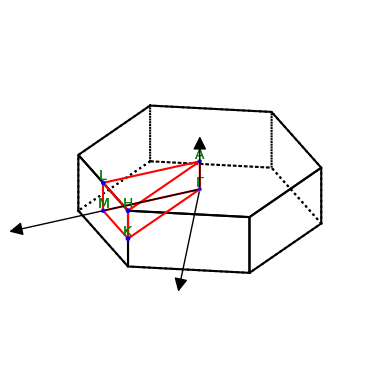

<Axes3D: >

In [17]:
lat = atoms.cell.get_bravais_lattice()
lat.plot_bz(show=True)

### Found $\Gamma \to K \to M \to \Gamma$ band path
### Plot the first 6 bands

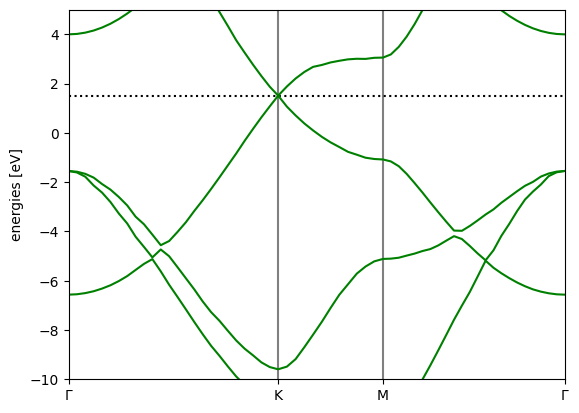

In [10]:
path = atoms.cell.bandpath('GKMG',npoints=61)
qe_options['&system']['nbnd']=6
band = atoms.calc.get_band_structure(qe_options, kpts=path, reference=atoms.calc.get_fermi_level())
bp=band.plot()

# Challenge 1.2

- Band structure of Si diamond structure
- Use the hands-on band structure tutorial and the `ASE` tool `Bulk` from `ase.build`
```
from ase.build import bulk
atoms = bulk('Si','diamond',a=5.431)
```


# PART II: TDDFT based on KS-DFT

# Real-time TDDFT equations :

$$
-\frac{1}{2}\nabla^2 \phi_k(\mathbf{r},t) + \color{red}{v_s(\mathbf{r},t)}\,\phi_k(\mathbf{r},t)
= i\,\frac{\partial \phi_k(\mathbf{r},t)}{\partial t}
$$

$$
n(\mathbf{r},t) = \sum_k f_k\, \lvert \phi_k(\mathbf{r},t) \rvert^2,
\qquad N = \sum_k f_k,
\quad \text{with } \{f_k\} \text{ time-independent.}
$$

### The rt-TDDFT equations can be integrated in time

 - It is possible to find a "propagator" such that

$$
\phi_k(\mathbf{r},t) = \hat U(t-t_0) \phi_k(\mathbf{r},t_0) \qquad \text{for each KS orbital}
$$

 - This approach delivers $\phi_k(\mathbf{r},t)$ and thus $n(\mathbf{r},t)$

 - ...and any other derived quantity

 - ultrafast electron dynamics (scattering, Coulomb explosions, stopping power, etc...)

 - electronic oscillations in the frequency domain, $n(\mathbf{r},\omega)$, give access to spectra

# However, we need the time-dependent KS potential

<br>

$$
v_s(\mathbf{r},t) = v_H(\mathbf{r},t) + v_{ext}(\mathbf{r},t) + \color{red}{v_{xc}(\mathbf{r},t)}
$$

is defined as the potential such that $n_{KS}(\mathbf{r},t) = n(\mathbf{r},t)$

Once $v_s(\mathbf{r},t)$ is approximated, we can integrate the rt-TDDFT equations finding propagators

Several software implement rt-TDDFT, and if time permits, we will consider it later in this lecture

# Challenge 2

- The occupation numbers, $\{f_k\}$, are taken to be independent of time. Why?

Discuss among the group and be ready to share your thoughts with the class.

<center><img src="../figures/random/qr_poll4.2.png" width=500 height=300 /></center>



# Challenge 3

- How can $v_s(\mathbf{r},t)$ be approximated? Would $v_{xc}(\mathbf{r},t) = \frac{\delta E_{xc}[n]}{\delta n(\mathbf{r})}\bigg\vert_{n=n(\mathbf{r},t)}$ be a good approximation?

Discuss among the group and be ready to share your thoughts with the class.

<center><img src="../figures/random/qr_poll4.3.png" width=500 height=300 /></center>



# The adiabatic approximation in TDDFT

$$
v_{xc}(r,t) = v_{xc}[n(r,t)](r)
$$
uses the ground state XC functional and potential and evaluates them with the time-dependent density, $n(r,t)$.

- The time-dependent xc potential is <b>not</b> defined in this way

- The adiabatic approximation is perhaps the best we can do. <b>But</b> together with the self-interaction error,  it leads to some shortcomings:
    - <a href="https://iopscience.iop.org/article/10.1088/1361-648X/aa836e/meta">charge-transfer excitations are generally too low in energy</a>
    - predicted optical gaps are usually too low (e.g., <a href="https://journals.aps.org/prb/abstract/10.1103/PhysRevB.73.094204">PBE water: 6.5 eV vs 8.5 eV</a>, see also <a href="https://pubs.acs.org/doi/10.1021/acs.jpclett.7b02212">this paper</a>.)
    - <a href="https://doi.org/10.1016/j.chemphys.2011.03.020">neglect of double excitations (e.g., 1,3-butene)</a>

- There are fixes <b>but you must evaluate them carfully before use</b>.
    - use of hybrids
    - use of GGA+U
    - use of long-range corrected xc potentials <a href="https://pubs.aip.org/aip/jcp/article-abstract/112/3/1344/184896/Molecular-calculations-of-excitation-energies-and">(LB94, SAOP)</a>
    - other functionals (Koopman's, etc)

# Does $v_{xc}(\mathbf{r},t)$ exist?


<br>
<br>
<center>
    <div class="alert alert-success">The KS-TDDFT equations are the result of the <a href="https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.52.997">Runge-Gross theorem</a>, the follow-up <a href="https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.82.3863">van Leuwen theorem</a> and considerations by <a href="https://journals.aps.org/pra/abstract/10.1103/PhysRevA.77.062511">Vignale</a>.</div>
</center>

# Targeting the excited states directly: linear-response TDDFT

**Idea:** consider **small variations**, $\delta v_{appl}$, of the external potential.

## In other words:
<br>
<center>the TDDFT equations define <b>variations</b> $\longleftrightarrow$ <b>response</b> relations as</center>

$$
\color{green}{\text{Int: }} v_{ext}(\mathbf{r},t) - v_{ext}(\mathbf{r},0)=\color{green}{\delta v_{appl}(\mathbf{r},t)  \longleftrightarrow \delta n(\mathbf{r},t)}=n(\mathbf{r},t) - n(\mathbf{r},0)
$$

$$
~~~~~~~~\color{red}{\text{KS: }}~v_s(\mathbf{r},t) - v_s(\mathbf{r},0)=\color{red}{\delta v_s(\mathbf{r},t)  \longleftrightarrow \delta n(\mathbf{r},t)} = n(\mathbf{r},t) - n(\mathbf{r},0)
$$

<center>and in frequency domain:</center>

$$
\color{green}{\delta v_{appl}(\mathbf{r},\omega)  \longleftrightarrow \delta n(\mathbf{r},\omega)} \qquad \color{red}{\delta v_s(\mathbf{r},\omega)  \longleftrightarrow \delta n(\mathbf{r},\omega)}
$$

<center>
    <div class="alert alert-success">We now express these relations in the limit of <b>linear response</b></div></center>

## Linear density response of the interacting system

For a weak perturbing potential $\delta v_{\mathrm{appl}}(\mathbf{r},\omega)$, the density response, $\delta n(\mathbf{r},\omega)$, satisfies

$$
\delta n(\mathbf{r},\omega) = \int \chi(\mathbf{r},\mathbf{r}',\omega)\, \delta v_{\mathrm{appl}}(\mathbf{r}',\omega)\, d\mathbf{r}' ~~  \color{green}{\longleftrightarrow} ~~ \chi(\mathbf{r},\mathbf{r}',\omega) = \frac{\delta n(\mathbf{r},\omega)}{\delta v_{\mathrm{appl}}(\mathbf{r}',\omega)}~~~~~~~~~~
$$

where $\chi$ is the density response function of the **interacting** system


<center>
    <div class="alert alert-danger">Does  $\delta n=\chi\delta v_{appl}$ make sense to you?</div>
</center>

### Why is $\chi$ interesting?

From 1$^{st}$ order PT, it can be shown that:
<div class="alert alert-success">
$$
\chi(\mathbf{r},\mathbf{r}',\omega) = \sum_n \frac{\rho_{0n}(\mathbf{r})\rho_{n0}(\mathbf{r}') }{\omega-\Omega_{0n}-i\eta} + cc
$$
</div>




<center>
    <div class="alert alert-danger">When $\omega = \Omega_{0n}$, $\chi$ has a "pole" $\longrightarrow$ information about <b>excitation energies</b> and <b>transition densities</b>!</div>
</center>


## Linear density response of the KS system

 - To find $\chi$ we once again consider the **Kohn–Sham** non-interacting system.

 - The interacting and KS systems bust share the same density reponse, $\delta n$ (using a short-hand notation)

<br><br>

<table style="width: 100%; border-collapse: collapse; font-size: 38px;">
  <tr>
    <td style="width: 50%; background-color: lightgreen; padding: 20px; border: 1px solid black;">
      $$\color{red}{\chi} \delta v_{appl}$$
    </td>
    <td style="width: 50%; background-color: lightyellow; padding: 20px; border: 1px solid black;">
      $$\chi_s \color{red}{\delta v_s}$$
    </td>
  </tr>
</table>

<br>


<br><br>
<center>
    <div class="alert alert-danger">the above is true for a <b>special $\delta v_s$</b> such that $\delta n$ of interacting and KS systems are <b>equal</b></div>
</center>

## What is $\color{red}{\delta v_s}$?

$$
\delta v_s(\mathbf{r},\omega) = \delta v_H(\mathbf{r},\omega) + \color{red}{\delta v_{\mathrm{xc}}(\mathbf{r},\omega)} + \delta v_{\mathrm{appl}}(\mathbf{r},\omega)
$$

with Hartree piece $\delta v_H(\mathbf{r},\omega) = \int \dfrac{\delta n(\mathbf{r}',\omega)}{|\mathbf{r}-\mathbf{r}'|}\, d\mathbf{r}'$ and <span style="color: red;">$\delta v_{xc}(\mathbf{r},\omega) = \int d\mathbf{r}' f_{\mathrm{xc}}[n](\mathbf{r},\mathbf{r}',\omega)\,\delta n(\mathbf{r}'\omega)$, where we have defined an **xc kernel**</span>.

Combining the definitions introduced thus far:

$$
\chi \delta v_{appl} = \chi_s \delta v_{appl} + \chi_s \bigg(f_{xc} + \frac{1}{|\mathbf{r}-\mathbf{r}'|}\bigg)\delta n
$$

by taking the derivative wrt $\delta v_{appl}$ we obtain an important relation
<br>
<br>
<center>
    <div class="alert alert-danger">
        $$
        \chi = \chi_s + \chi_s f_{Hxc} \chi
        $$
    </div>
</center>
    

## Casida equations

The inverse of the Dyson equation is

$$
-\chi^{-1} = -\chi_s^{-1} + f_{Hxc}(\mathbf{r},\mathbf{r}',\omega)
$$

can be expressed in a basis set of occupied/virtual products, leading to the **Casida equation**

$$
\begin{pmatrix} {\bf A}(\omega) & {\bf B}(\omega) \\ {\bf B}(\omega) & {\bf A}(\omega) \end{pmatrix} \begin{pmatrix} X_{ia} \\ Y_{ia} \end{pmatrix} = \omega \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} \begin{pmatrix} X_{ia} \\ Y_{ia} \end{pmatrix}
$$

where
$$
A_{iajb}(\omega) = \delta_{ij}\delta_{ab}\,\omega_{ia} + \big\langle \phi_i \phi_a \big| f_{Hxc}(\mathbf{r},\mathbf{r}',\omega) \big| \phi_j \phi_b \big\rangle, \qquad
B_{iajb}(\omega) = \big\langle \phi_i \phi_a \big| f_{Hxc}(\mathbf{r},\mathbf{r}',\omega) \big| \phi_j \phi_b \big\rangle
$$

with $\omega_{ia} = \varepsilon_a - \varepsilon_i$, are the KS orbital excitations.


Excitation energies $\Omega_n$ and the eigenvectors $(X_{ia}, Y_{ia})$ deliver transition densities $\rho_{0n}(\mathbf{r}) = \sum_{ia} (X_{ia}+Y_{ia})\phi_i(\mathbf{r})\phi_a(\mathbf{r})$.

## What can you obtain from lr-TDDFT?

- excitation energies / spectral line positions
- check out <a href="https://arxiv.org/pdf/1108.0611"> this nice paper</a>

 - transition densities, transition dipoles and other derived quantities

 - e-e structure factors, dielectric functions, etc...
 - you'll learn about some of these applications next week

# Ready for some hands-on work?

- lr-TDDFT with QEpy:
    - lr-tddft:  [`tddfpt_qepy.ipynb`](../tutorials/qepy/lr-tddft/tddfpt_qepy.ipynb)

# Integrating the TDDFT equations in real time (rt)

The main idea: use a <b>propagator</b>!
$$
\phi_i(t+dt) = \hat U(t,t+dt)\, \phi_i(t)
$$

It is formally defined as follows for time-independent Hamiltonians:
$$
\hat U(t,t+dt) = e^{-i\hat H\, dt}
$$

Where for KS-TDDFT one would like to write

$$
\color{red}{
\hat H = \hat h_{\mathrm{KS}} = -\frac{1}{2}\nabla^2 + v_s(\mathbf{r},t)
}
$$


# Challenge 5
 - Derive $\hat U(t,t+dt) = e^{-i\hat H dt}$ from the time-dependent Schrödinger equation for <b>time-independent </b> Hamiltonians


<div style="text-align:center; max-width:900px; margin:0 auto; border:1px solid #e6c200; background:#fcf8e3; padding:12px 16px;">
<b>Hint</b><br>
Use a Taylor expansion of the propagator / wavefunction in the time step (see display below).
</div>

$$
\phi(t+dt) \simeq \phi(t) + \frac{d \phi(t)}{dt}\, dt + \frac{1}{2}\, \frac{d^2 \phi(t)}{dt^2}\, dt^2 + \cdots
$$


# There are complications

- the exponential function is of difficult implementation because it implies diagonalization of the Hamiltonian (almost always not a viable option), or a Taylor expansion $$ e^{M}=1+M+\frac{M^2}{2}+\cdots $$

- The Hamiltonian (KS and OF) contains time-dependent potentials, for example the externally applied potential, $v_{appl}(r,t)$.

# Time-dependence of $\hat H$

# Real-time TDDFT

<center>
    <div class="alert alert-success">Real-time TDDFT refers to the integration of the KS/OF-TDDFT equations discretizing time and propagating the occupied orbitals with specialized propagators.</div>
</center>

In rt-TDDFT, propagators are iteratively applied, e.g.:

``` python
phi[0]={ground state occupied orbital(s)}
for i in range(1,N_max):
    phi[i] = U(t,t+dt) phi[i-1]
```

$\hat U(t,t+dt)$ needs to be approximated

Simplest is Taylor expansion of $\hat U=e^{-i\hat H(t) dt}$: $U(t,t+dt)\simeq 1 - i \hat H dt$

## Better idea ... 

<center><img src="../figures/science/cn_time_line.png" width=1000 /></center>

# Crank-Nicolson (CN) propagator

The most common propagator to use is the Crank-Nicolson (CN) propagator:
$$
\hat U(t,t+dt) \simeq \frac{1-i\hat H(t+\frac{dt}{2})\frac{dt}{2}}{1+i\hat H(t+\frac{dt}{2})\frac{dt}{2}}
$$
which propagates with an error of the order of $dt^3$ and is stable regardless of the initial conditions.

- CN conserves the norm, $\langle \phi_i(t) | \phi_i(t)\rangle = \langle \phi_i(t+dt) | \phi_i(t+dt)\rangle = 1$.

- CN may require <b>predictor-corrector</b> steps to better evaluate $\hat H(t+\frac{1}{2}dt)$ and deliver a physical electron dynamics.

- There are many other propagators (ETRS, ...). <a href="https://pubs.aip.org/aip/jcp/article-abstract/121/8/3425/464718/Propagators-for-the-time-dependent-Kohn-Sham?redirectedFrom=fulltext">Check out this nice paper</a> and <a href="https://www.octopus-code.org/documentation/main/manual/calculations/time-dependent/">this nice intro</a> in the OCTOPUS manual.

# Challenge 6

- Derive the Crank–Nicolson (CN) propagator: express $\phi\left(t + \frac{\Delta t}{2}\right)$ from $\phi(t)$ (forward propagation) and $\phi(t+\Delta t)$ (backward propagation), using Taylor expansions in $\Delta t$.
- **Optional:** show that the CN propagator conserves the norm. *Hint:* check the norm directly; the propagator is unitary, so the adjoint equals its inverse.

# What is real-time TDDFT useful for?

- Optical spectra (KS):
    - <a href="https://journals.aps.org/prb/abstract/10.1103/PhysRevB.73.094204">Liquid water</a> and <a href="https://pubs.acs.org/doi/10.1021/acs.jpclett.7b02212">another liquid water</a>
    - <a href="https://pubs.acs.org/doi/10.1021/acsnanoscienceau.2c00061">Metallic systems (plasmons)</a>    

- Optical spectra (OF):
    - <a href="https://journals.aps.org/prb/pdf/10.1103/PhysRevB.104.235110">Nanoparticles</a> and <a href="https://pubs.acs.org/doi/full/10.1021/acs.nanolett.2c01399">other plasmonic systems</a>

- Electron-nuclear dynamics in non-equilibrium systems (KS):
    - <a href="https://www.nature.com/articles/s41524-023-01157-7">Materials stopping power (alpha particles, protons, etc)</a>
    - <a href="https://www.pnas.org/doi/full/10.1073/pnas.1518224112">Polaritonic systems</a>
    - <a href="https://pubs.acs.org/doi/10.1021/acs.jpca.3c03709">Non-equilibrium electron nuclear dynamics (Ehrenfest) of charge-transfer dynamics</a>

- Electron-nuclear dynamics in non-equilibrium systems (OF):
    - <a href="https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.121.145001">Warm dense matter</a>

# Ready for some hands-on work?

- rt-TDDFT with QEpy:
    - lr-tddft:  [`tddfpt_qepy.ipynb`](../tutorials/qepy/lr-tddft/tddfpt_qepy.ipynb)